In [1]:
import torch
from PIL import Image
from torchvision import transforms
from pathlib import Path
from functools import cache
from torchmetrics.functional.classification import multiclass_f1_score
from torchmetrics.functional.segmentation import mean_iou, dice_score
from typing import List
from celeb_a_mask_hq import LABELS
import matplotlib.pyplot as plt

In [ ]:
original_image_path = Path("./eval-set/images-150/")
all_image_paths = list(original_image_path.glob("*.jpg"))
# masks_path = Path("./eval-set/masks-512/") # for sam3 and old CV models
masks_path = Path("./eval-set/masks-1024/") # for MLLM
mask_transform = transforms.PILToTensor()
image_ids = {image.stem for image in all_image_paths}
image_ids_list = sorted(list(image_ids))
# attempts = 1 # for sam3 and old CV models
attempts = 3 # for MLLM


@cache
def get_mask_ref(image_id: str, return_image: bool) -> torch.Tensor:
    mask_path = masks_path / f"{image_id}.png"
    mask = Image.open(mask_path)
    if return_image:
        return mask
    mask = mask_transform(mask)
    assert mask.dtype == torch.uint8
    assert mask.max() <= 18
    return mask


result_paths = {
    # "gemini-pro": Path("./results/gemini-pro-150"),
    # "gemini-pro-shuffled": Path("./results/gemini-pro-150-shuffled-label-colors"),
    # "gemini": Path("./results/gemini-150"),
    # "gpt": Path("./results/gpt-image-150"),
    "sam3": Path("./results/sam3-150"),
}


def get_mask_pred(image_id: str, model: str, return_image: bool) -> List[torch.Tensor]:
    result_path = result_paths[model]
    masks = []
    for i in range(attempts):
        mask_path = result_path / f"{image_id}.mask.{i}.pred.png"
        mask = Image.open(mask_path)
        if return_image:
            masks.append(mask)
            continue
        mask = mask_transform(mask)
        assert mask.dtype == torch.uint8
        assert mask.max() <= 18
        masks.append(mask)
    return masks

In [3]:
LOAD_METRICS = False

In [4]:
if LOAD_METRICS:
    raise Exception("LOAD_METRICS is True")

metric_f1 = {}
metric_iou = {}
metric_dice = {}
label_num = len(LABELS)




for model, result_path in result_paths.items():
    f1_scores = []
    iou_scores = []
    dice_scores = []
    for image_id in image_ids_list:
        mask_ref = get_mask_ref(image_id, return_image=False)
        masks_pred = get_mask_pred(image_id, model, return_image=False)
        assert mask_ref.shape == masks_pred[0].shape

        f1_score = torch.empty(attempts)
        for i, mask_pred in enumerate(masks_pred):
            f1 = multiclass_f1_score(
                mask_pred, mask_ref, num_classes=label_num, average="macro"
            )
            f1_score[i] = f1
        f1_scores.append(f1_score)

        mask_ref = mask_ref.long()
        for i in range(attempts):
            masks_pred[i] = masks_pred[i].long()

        iou_score = torch.empty(attempts)
        for i, mask_pred in enumerate(masks_pred):
            iou = mean_iou(
                mask_pred, mask_ref, num_classes=label_num, input_format="index"
            )
            iou_score[i] = iou
        iou_scores.append(iou_score)

        dice = torch.empty(attempts)
        for i, mask_pred in enumerate(masks_pred):
            d = dice_score(
                mask_pred,
                mask_ref,
                num_classes=label_num,
                average="macro",
                input_format="index",
            )
            dice[i] = d
        dice_scores.append(dice)

    f1_scores = torch.stack(f1_scores)
    metric_f1[model] = f1_scores
    iou_scores = torch.stack(iou_scores)
    metric_iou[model] = iou_scores
    dice_scores = torch.stack(dice_scores)
    metric_dice[model] = dice_scores

In [ ]:
import pickle

metrics_pkl_path = Path("metrics_sam3.pkl") # for sam3
# metrics_pkl_path = Path("metrics.pkl") # for MLLM

if metrics_pkl_path.exists() and LOAD_METRICS:
    with open(metrics_pkl_path, "rb") as f:
        metrics = pickle.load(f)
elif not metrics_pkl_path.exists() and LOAD_METRICS:
    raise Exception("LOAD_METRICS is True but metrics.pkl does not exist")
elif not metrics_pkl_path.exists() and not LOAD_METRICS:
    metrics = {
            "f1": metric_f1,
            "iou": metric_iou,
            "dice": metric_dice,
        }
    with open(metrics_pkl_path, "wb") as f:
        pickle.dump(metrics, f)
else:
    pass
        

In [7]:
def plot_best_worst_mask(metric: torch.Tensor, metric_name: str, model: str):
    m = metric.max(dim=1)
    max_scores = m.values
    max_value = max_scores.max()
    max_column_indices = m.indices
    # row for image, column for attemps
    max_row_index = max_scores.argmax()
    max_col_index = max_column_indices[max_row_index]
    best_image_id = image_ids_list[max_row_index.item()]
    best_attempt = max_col_index.item()

    image = Image.open(original_image_path / f"{best_image_id}.jpg")
    mask_ref = get_mask_ref(best_image_id, return_image=True)
    mask_pred = get_mask_pred(best_image_id, model, return_image=True)[best_attempt]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(mask_ref)
    axes[1].set_title("Reference Mask")
    axes[1].axis("off")
    axes[2].imshow(mask_pred)
    axes[2].set_title(f"Best Predicted Mask - {metric_name}: {max_value:.4f}")
    axes[2].axis("off")
    plt.show()

    m = metric.min(dim=1)
    min_scores = m.values
    min_value = min_scores.min()
    min_column_indices = m.indices
    # row for image, column for attemps
    min_row_index = min_scores.argmin()
    min_col_index = min_column_indices[min_row_index]
    worst_image_id = image_ids_list[min_row_index.item()]
    worst_attempt = min_col_index.item()

    image = Image.open(original_image_path / f"{worst_image_id}.jpg")
    mask_ref = get_mask_ref(worst_image_id, return_image=True)
    mask_preds = get_mask_pred(worst_image_id, model, return_image=True)
    worst_mask_pred = mask_preds[worst_attempt]
    other_mask_preds = [mask_preds[i] for i in range(attempts) if i != worst_attempt]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # First row: original, reference, worst predicted
    axes[0, 0].imshow(image)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(mask_ref)
    axes[0, 1].set_title("Reference Mask")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(worst_mask_pred)
    axes[0, 2].set_title(f"Worst Predicted Mask - {metric_name}: {min_value:.4f}")
    axes[0, 2].axis("off")

    # Second row: the other 2 mask preds
    for idx, mask in enumerate(other_mask_preds):
        axes[1, idx].imshow(mask)
        axes[1, idx].set_title(f"Other Mask Pred {idx + 1}")
        axes[1, idx].axis("off")

    # Hide any unused axes in the second row (in case attemps < 3)
    for idx in range(len(other_mask_preds), 3):
        axes[1, idx].axis("off")

    plt.tight_layout()
    plt.show()

    return best_image_id, best_attempt, worst_image_id, worst_attempt

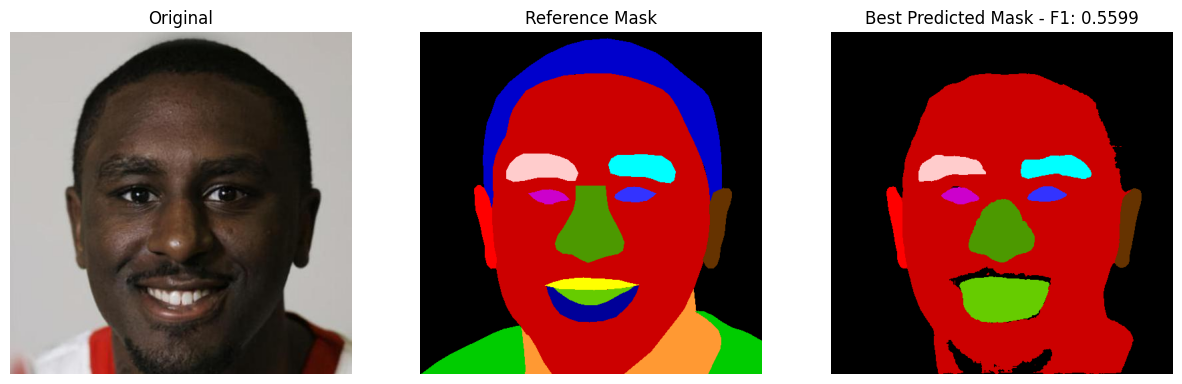

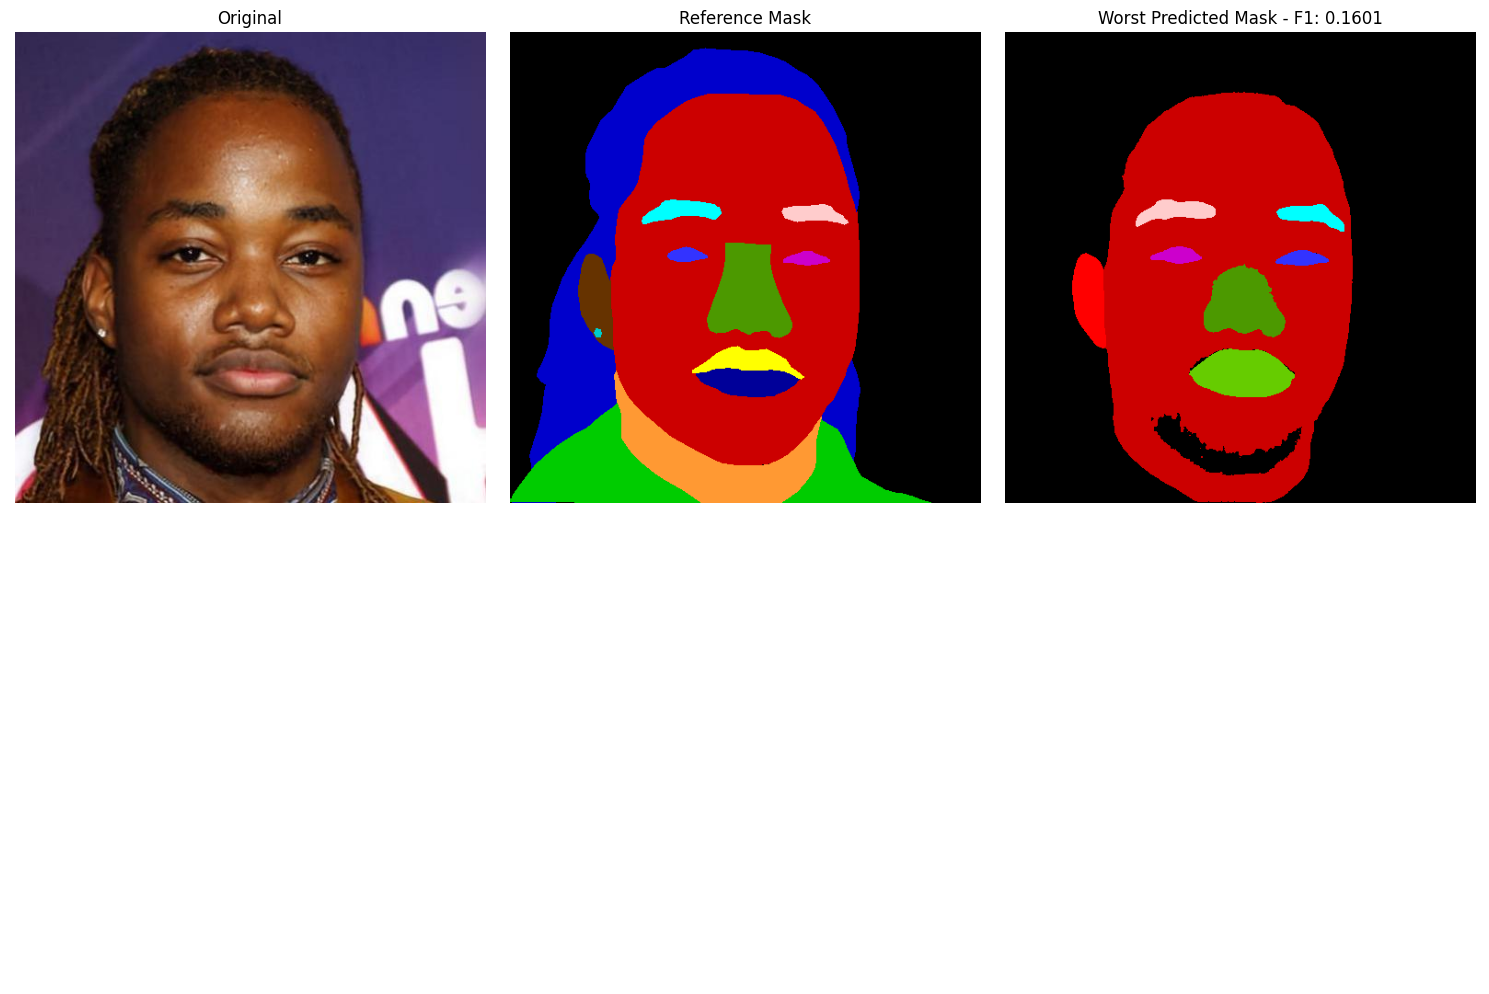

('3ac9e4bfc2f343c693b897780a721bdb', 0, '106a0c76023a4aceaa538a25de9cffb7', 0)


In [ ]:
model = "sam3"
metric_name = "f1"
print(
    plot_best_worst_mask(
        metric=metrics[metric_name][model], metric_name=metric_name, model=model
    )
)
# print(plot_best_worst_mask(metric_iou["gemini-pro"], "IoU", "gemini-pro"))
# print(plot_best_worst_mask(metric_dice["gemini-pro"], "Dice", "gemini-pro"))